VUFC Final Project

Cohen ter Heide (301549869)
Client proposal: Faaiz Abdullah (301472058)

Two questions: who will renew for fall, and why did people join. Charts below build toward a spend recommendation for VUFC leadership.


Progress Report

Project overview

Vancouver United Football Club (VUFC) experienced a membership surge during the 2026 FIFA World Cup. Leadership must decide whether to expand capacity, invest in marketing, or focus on retaining the new cohort.

Renewal prediction: rank new registrants by likelihood of fall renewal using signup and early attendance data.
Survey theme discovery: extract actionable themes from optional free-text intake responses.

Current stage

EDA: Complete
Renewal prediction model: Complete
Survey theme extraction: Complete
Strategic option ranking: Complete
Streamlit stakeholder dashboard: Complete
Final delivery: Ready

Key findings

Paid marketing ranked first: World Cup momentum and survey demand support another acquisition push on fan fest and online channels.
Expand pitch space ranked second: distance and cohort scale justify capacity investment.
Retention outreach system ranked third: model produces a useful at-risk list as supporting infrastructure.

Setup


In [1]:
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_processing import SESSION_COLS, build_modeling_frame, load_signups, load_survey

RANDOM_STATE = 461
GREEN, RED, BLUE = "#2e7d32", "#c62828", "#1565c0"
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
sns.set_theme(style="whitegrid")

signups_raw = load_signups()
survey = load_survey()
df = build_modeling_frame(signups_raw, survey)
print(f"{len(df)} members | {df['renewed_fall_season'].mean():.0%} renewed | {survey.shape[0]} survey responses")


1000 members | 63% renewed | 420 survey responses


Loads libraries, project paths, and the cleaned modeling dataset. Run this cell first.


Channel volume vs retention


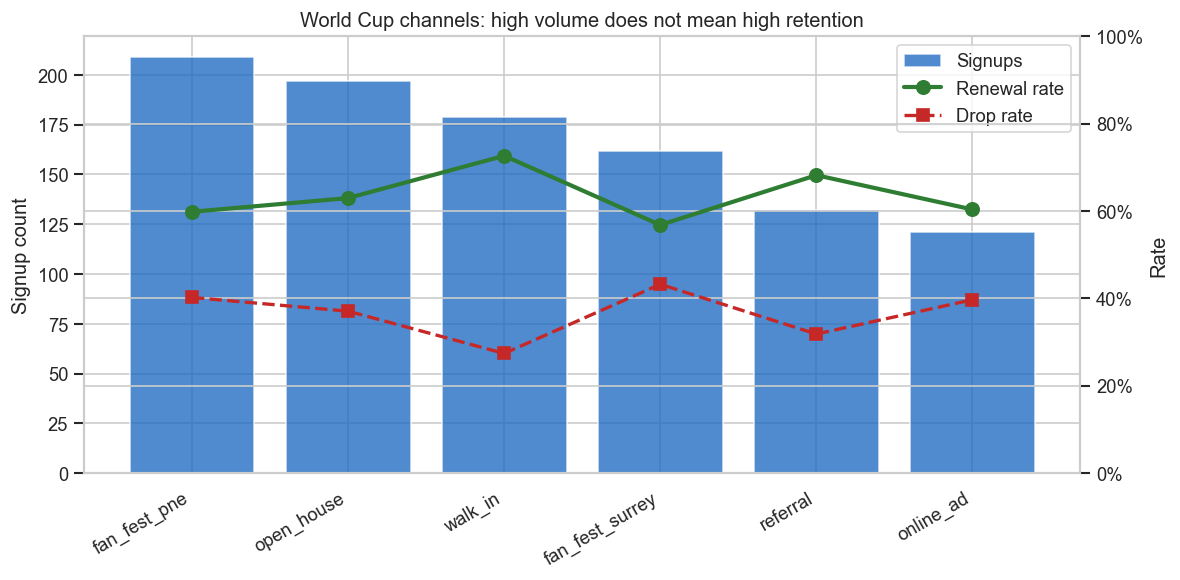

,signup_channel,signups,renewal_rate,drop_rate
0,fan_fest_pne,209,59.8,40.2
3,open_house,197,62.9,37.1
5,walk_in,179,72.6,27.4
1,fan_fest_surrey,162,56.8,43.2
4,referral,132,68.2,31.8
2,online_ad,121,60.3,39.7


In [2]:
#Signup volume vs renewal rate by channel
channel_stats = df.groupby("signup_channel").agg(
    signups=("member_id", "count"),
    renewal_rate=("renewed_fall_season", "mean"),
).reset_index()
channel_stats["drop_rate"] = 1 - channel_stats["renewal_rate"]
channel_stats = channel_stats.sort_values("signups", ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(channel_stats))
bars = ax1.bar(x, channel_stats["signups"], color=BLUE, alpha=0.75, label="Signups")
ax1.set_ylabel("Signup count")
ax1.set_xticks(x)
ax1.set_xticklabels(channel_stats["signup_channel"], rotation=30, ha="right")

ax2 = ax1.twinx()
ax2.plot(x, channel_stats["renewal_rate"], "o-", color=GREEN, lw=2.5, ms=8, label="Renewal rate")
ax2.plot(x, channel_stats["drop_rate"], "s--", color=RED, lw=2, ms=7, label="Drop rate")
ax2.set_ylabel("Rate")
ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")

lines = bars.patches + ax2.lines
labels = ["Signups", "Renewal rate", "Drop rate"]
ax1.legend(lines[:1] + ax2.lines, labels, loc="upper right")
ax1.set_title("World Cup channels: high volume does not mean high retention")
plt.tight_layout()
plt.show()

channel_stats.assign(
    renewal_rate=(channel_stats["renewal_rate"] * 100).round(1),
    drop_rate=(channel_stats["drop_rate"] * 100).round(1),
)[["signup_channel", "signups", "renewal_rate", "drop_rate"]]


Compares signup count and renewal rate by channel. Shows that high-volume World Cup marketing channels do not retain as well as walk-in and referral signups.


Attendance patterns


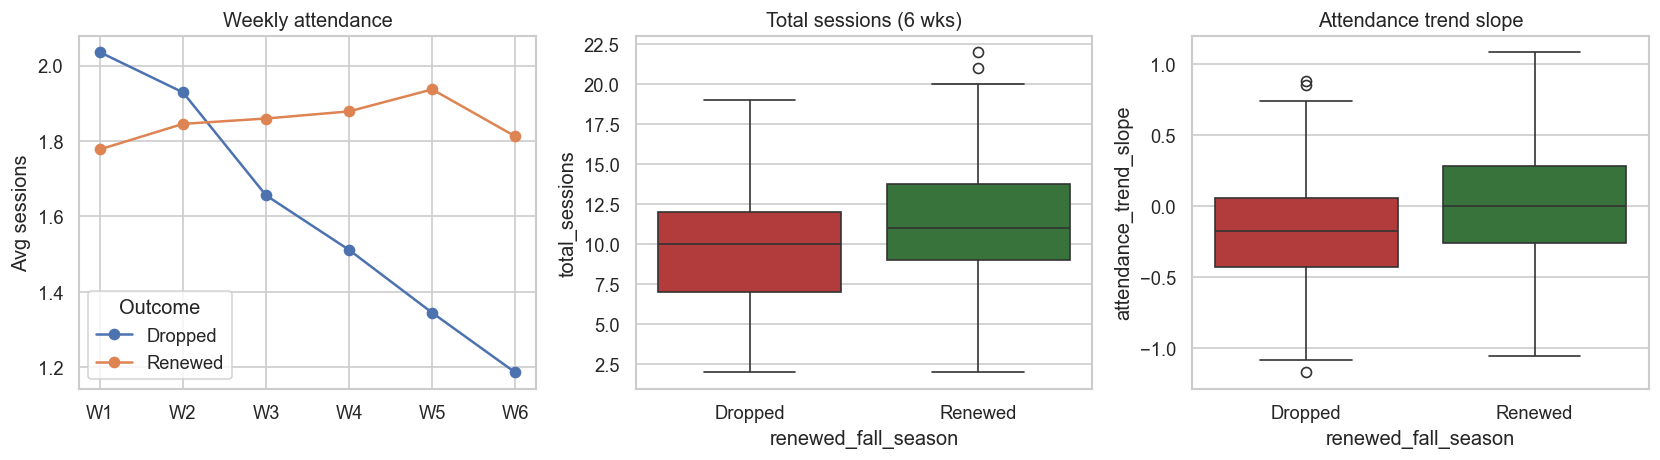

In [3]:
# Attendance separates renewers from dropouts
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

weekly = df.groupby("renewed_fall_season")[SESSION_COLS].mean()
weekly.index = ["Dropped", "Renewed"]
weekly.columns = [f"W{i}" for i in range(1, 7)]
weekly.T.plot(ax=axes[0], marker="o")
axes[0].set_title("Weekly attendance")
axes[0].set_ylabel("Avg sessions")
axes[0].legend(title="Outcome")

sns.boxplot(data=df, x="renewed_fall_season", y="total_sessions", ax=axes[1],
            palette=[RED, GREEN], order=[0, 1])
axes[1].set_xticklabels(["Dropped", "Renewed"])
axes[1].set_title("Total sessions (6 wks)")

sns.boxplot(data=df, x="renewed_fall_season", y="attendance_trend_slope", ax=axes[2],
            palette=[RED, GREEN], order=[0, 1])
axes[2].set_xticklabels(["Dropped", "Renewed"])
axes[2].set_title("Attendance trend slope")

plt.tight_layout()
plt.show()


Plots weekly attendance, total sessions, and attendance trend for members who renewed vs dropped. Early engagement separates the two groups.


Distance and family enrollment


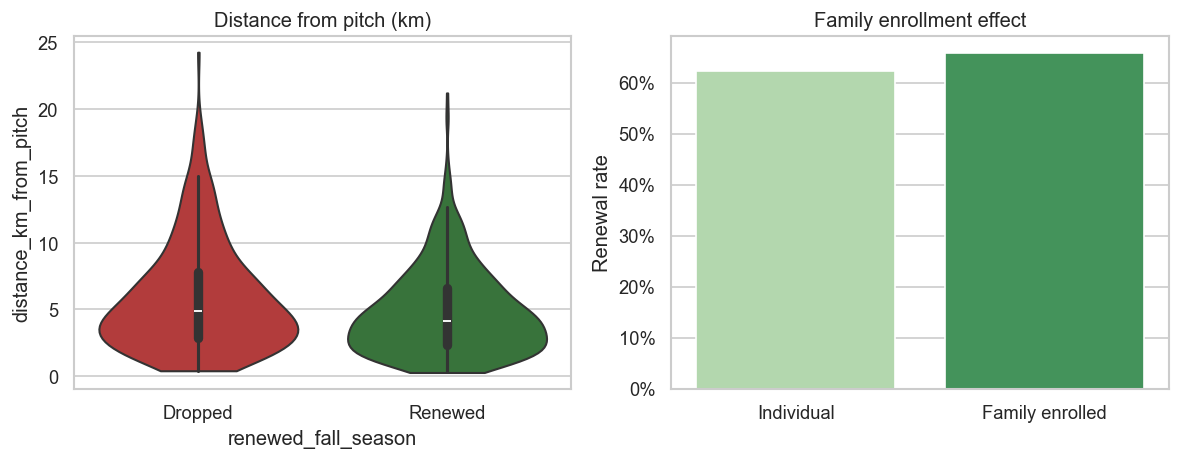

In [4]:
# Distance and family enrollment
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.violinplot(data=df, x="renewed_fall_season", y="distance_km_from_pitch", ax=axes[0],
               palette=[RED, GREEN], order=[0, 1], cut=0)
axes[0].set_xticklabels(["Dropped", "Renewed"])
axes[0].set_title("Distance from pitch (km)")

fam = df.groupby("family_enrolled")["renewed_fall_season"].mean().reset_index()
fam["label"] = fam["family_enrolled"].map({True: "Family enrolled", False: "Individual"})
sns.barplot(data=fam, x="label", y="renewed_fall_season", ax=axes[1], palette="Greens")
axes[1].set_ylabel("Renewal rate")
axes[1].yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
axes[1].set_title("Family enrollment effect")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()


Checks whether travel distance and family enrollment relate to renewal. Supporting context for outreach targeting.


Renewal prediction model


In [5]:
# Renewal prediction model
TARGET = "renewed_fall_season"
feature_cols = [
    "signup_channel", "age_bracket", "program_type", "prior_soccer_experience",
    "distance_km_from_pitch", "family_enrolled", "family_members_count",
    "communications_opt_in", "total_sessions", "avg_sessions_per_week",
    "attendance_trend_slope", "weeks_active", "max_weekly_sessions", "has_survey",
]
cat_features = ["signup_channel", "age_bracket", "program_type", "prior_soccer_experience"]
num_features = [c for c in feature_cols if c not in cat_features]

X, y = df[feature_cols], df[TARGET]
preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_features),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_features),
])

log_reg = Pipeline([("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))])
rf = Pipeline([("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE))])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

for name, model in [("Logistic regression", log_reg), ("Random forest", rf)]:
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    model.fit(X_train, y_train)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"{name}: CV AUC {scores.mean():.3f} | test AUC {auc:.3f}")

best = log_reg if roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]) >= roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]) else rf
best.fit(X_train, y_train)
test_proba = best.predict_proba(X_test)[:, 1]


Logistic regression: CV AUC 0.697 | test AUC 0.707
Random forest: CV AUC 0.675 | test AUC 0.687


Random forest: CV AUC 0.675 | test AUC 0.687


Trains logistic regression and random forest on signup and attendance features. Reports cross-validation and test AUC.


Model evaluation


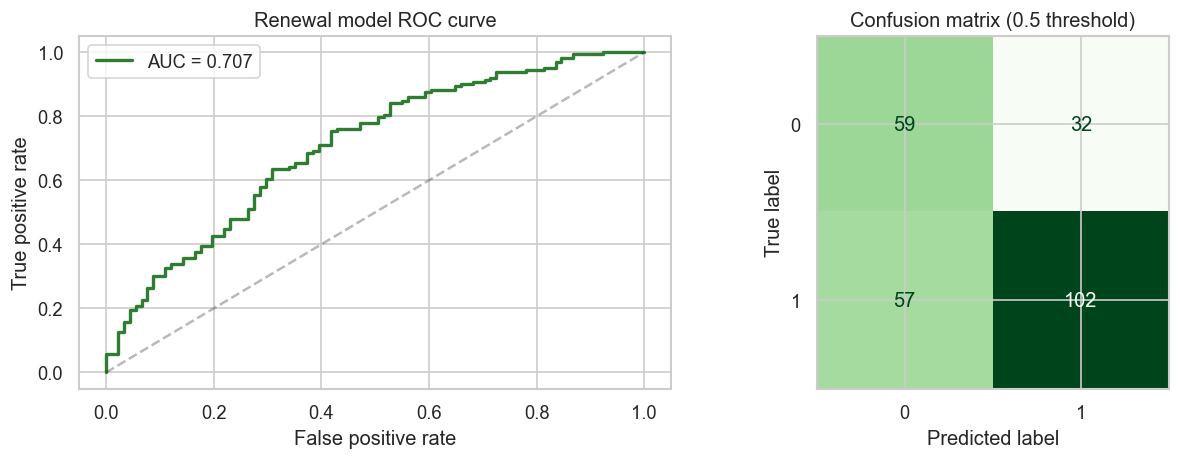

              precision    recall  f1-score   support

        Drop       0.51      0.65      0.57        91
       Renew       0.76      0.64      0.70       159

    accuracy                           0.64       250
   macro avg       0.63      0.64      0.63       250
weighted avg       0.67      0.64      0.65       250



In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[0].plot(fpr, tpr, color=GREEN, lw=2, label=f"AUC = {roc_auc_score(y_test, test_proba):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="Renewal model ROC curve")
axes[0].legend()

ConfusionMatrixDisplay(confusion_matrix(y_test, (test_proba >= 0.5).astype(int))).plot(
    ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("Confusion matrix (0.5 threshold)")

plt.tight_layout()
plt.show()
print(classification_report(y_test, (test_proba >= 0.5).astype(int), target_names=["Drop", "Renew"]))


ROC curve and confusion matrix for the renewal classifier on the held-out test set.


At-risk list and feature importance


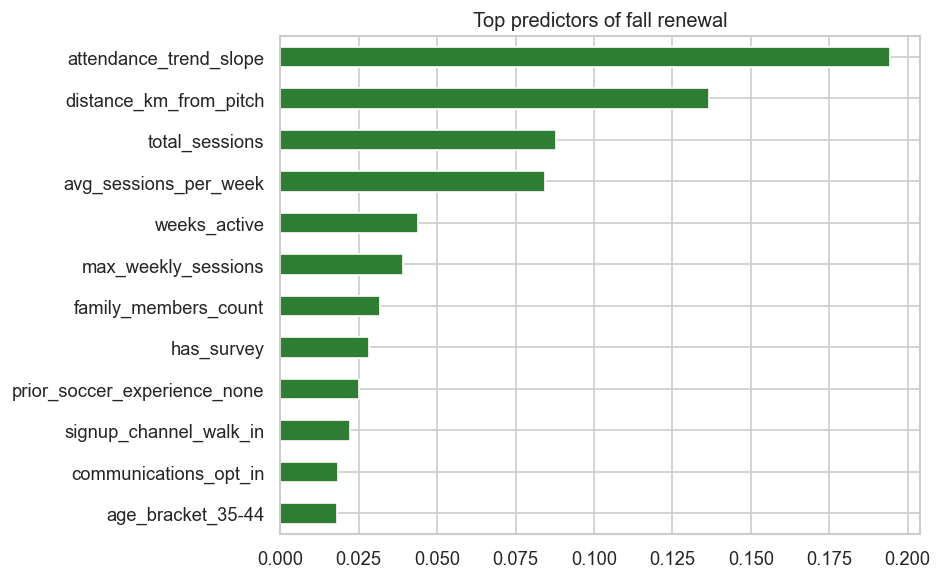

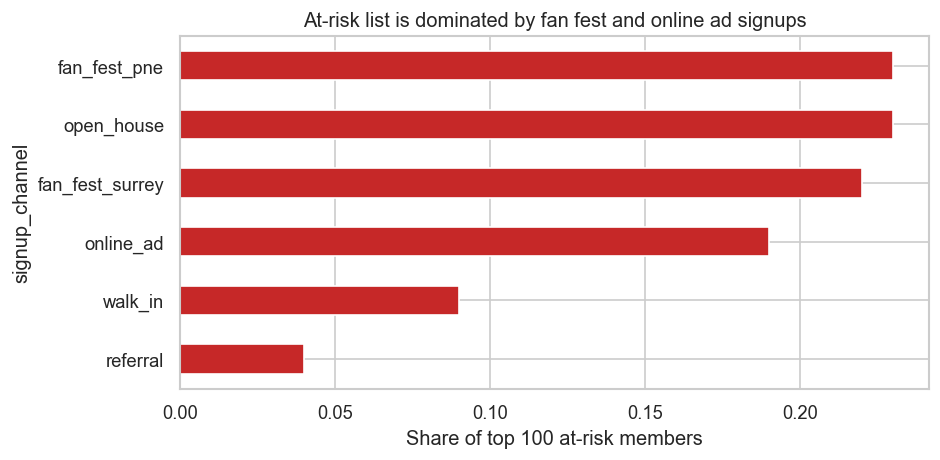

,member_id,signup_channel,total_sessions,renewed_fall_season,drop_risk
514,VU00515,open_house,3,0,0.953398
182,VU00183,fan_fest_pne,11,1,0.941847
166,VU00167,fan_fest_pne,8,0,0.917920
83,VU00084,fan_fest_pne,9,0,0.909827
134,VU00135,fan_fest_surrey,10,0,0.907472
622,VU00623,fan_fest_pne,8,0,0.905851
199,VU00200,fan_fest_pne,9,0,0.901901
906,VU00907,fan_fest_surrey,10,0,0.897199
846,VU00847,open_house,8,0,0.893308
154,VU00155,fan_fest_surrey,9,1,0.890833


In [7]:
#Feature importance + at-risk outreach list
rf.fit(X_train, y_train)
prep = rf.named_steps["prep"]
mdl = rf.named_steps["model"]
names = num_features + list(prep.named_transformers_["cat"].named_steps["oh"].get_feature_names_out(cat_features))
imp = pd.Series(mdl.feature_importances_, index=names).sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind="barh", ax=ax, color=GREEN)
ax.set_title("Top predictors of fall renewal")
plt.tight_layout()
plt.show()

df["renewal_prob"] = best.predict_proba(X)[:, 1]
df["drop_risk"] = 1 - df["renewal_prob"]
at_risk = df.sort_values("drop_risk", ascending=False)

#Where are at-risk members coming from?
top100 = at_risk.head(100)
risk_by_channel = top100["signup_channel"].value_counts(normalize=True).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
risk_by_channel.plot(kind="barh", ax=ax, color=RED)
ax.set_xlabel("Share of top 100 at-risk members")
ax.set_title("At-risk list is dominated by fan fest and online ad signups")
plt.tight_layout()
plt.show()

at_risk[["member_id", "signup_channel", "total_sessions", "renewed_fall_season", "drop_risk"]].head(15)


Shows which features drive renewal predictions and which channels dominate the top 100 at-risk members.


Survey theme clustering


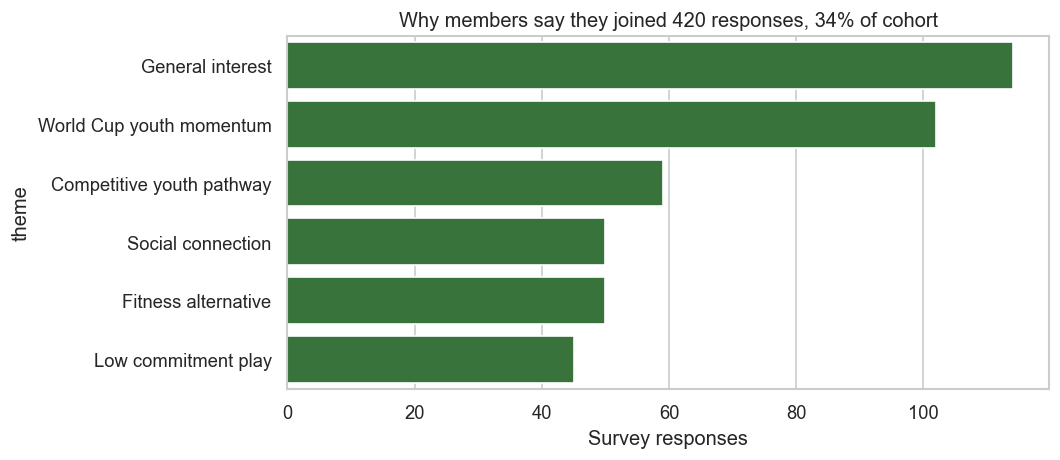

,cluster,theme,top_terms
0,0,Fitness alternative,"active, soccer, weight, looking lose, lose, lo..."
1,1,Competitive youth pathway,"looking, just, want, thinks son, thinks, coach"
2,2,Social connection,"actually, weekends, wanted, people, actually p..."
3,3,General interest,"saw, figured, year old, year, old, league"
4,4,World Cup youth momentum,"start, club, kid, world cup, world, cup"
5,5,Low commitment play,"don, don want, street, commitment don, want tr..."


In [8]:
#Survey themes TF-IDF + KMeans
def clean_text(t):
    t = re.sub(r"[^a-z0-9\s']", " ", str(t).lower())
    return re.sub(r"\s+", " ", t).strip()

survey = survey.copy()
survey["clean"] = survey["free_text_response"].apply(clean_text)
vec = TfidfVectorizer(max_features=800, stop_words="english", ngram_range=(1, 2), min_df=3)
X_text = vec.fit_transform(survey["clean"])
km = KMeans(6, random_state=RANDOM_STATE, n_init=30).fit(X_text)
survey["cluster"] = km.labels_

terms = np.array(vec.get_feature_names_out())
order = km.cluster_centers_.argsort()[:, ::-1]

def label_cluster(top):
    t = top.lower()
    if "world cup" in t or ("tv" in t and "old" in t): return "World Cup youth momentum"
    if "coach" in t or "club" in t: return "Competitive youth pathway"
    if "friends" in t or "people" in t: return "Social connection"
    if "gym" in t or "active" in t or "weight" in t: return "Fitness alternative"
    if "casual" in t or "commitment" in t or "intense" in t: return "Low commitment play"
    if "country" in t or "miss" in t: return "Returning to the game"
    return "General interest"

cluster_info = []
for i in range(6):
    top = ", ".join(terms[order[i, :6]])
    cluster_info.append({"cluster": i, "theme": label_cluster(top), "top_terms": top})
cluster_map = pd.DataFrame(cluster_info)
survey["theme"] = survey["cluster"].map(dict(zip(cluster_map["cluster"], cluster_map["theme"])))

theme_counts = survey["theme"].value_counts()
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=theme_counts.values, y=theme_counts.index, ax=ax, color=GREEN)
ax.set_xlabel("Survey responses")
ax.set_title("Why members say they joined 420 responses, 34% of cohort")
plt.tight_layout()
plt.show()
cluster_map


TF-IDF vectorization and KMeans clustering on free-text survey responses. Labels six member motivation themes.


Themes vs form categories


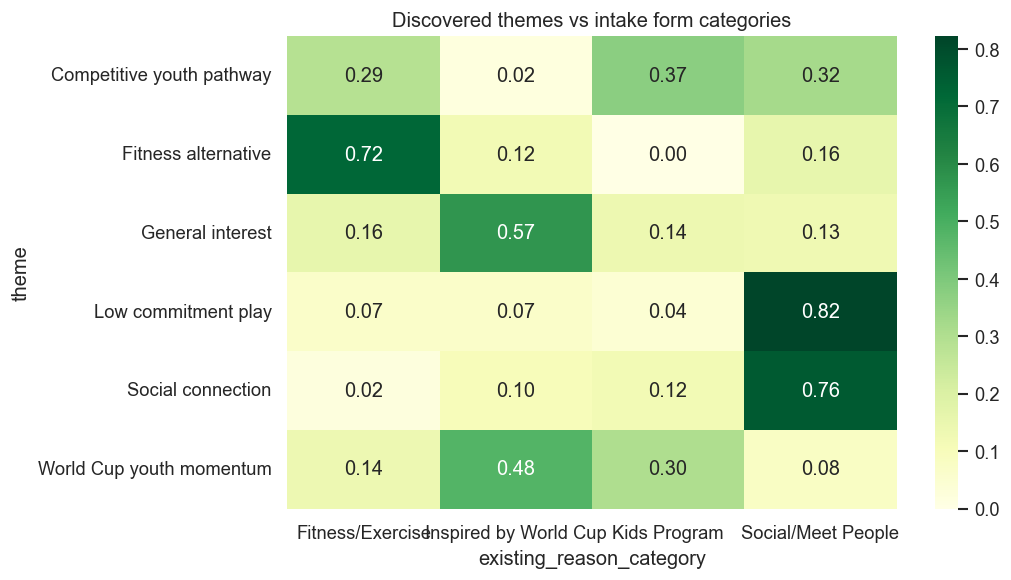

In [9]:
cross = pd.crosstab(survey["theme"], survey["existing_reason_category"], normalize="index")
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(cross, annot=True, fmt=".2f", cmap="YlGn", ax=ax)
ax.set_title("Discovered themes vs intake form categories")
plt.tight_layout()
plt.show()


Heatmap comparing discovered themes to the intake form's existing reason categories.


Retention vs marketing summary


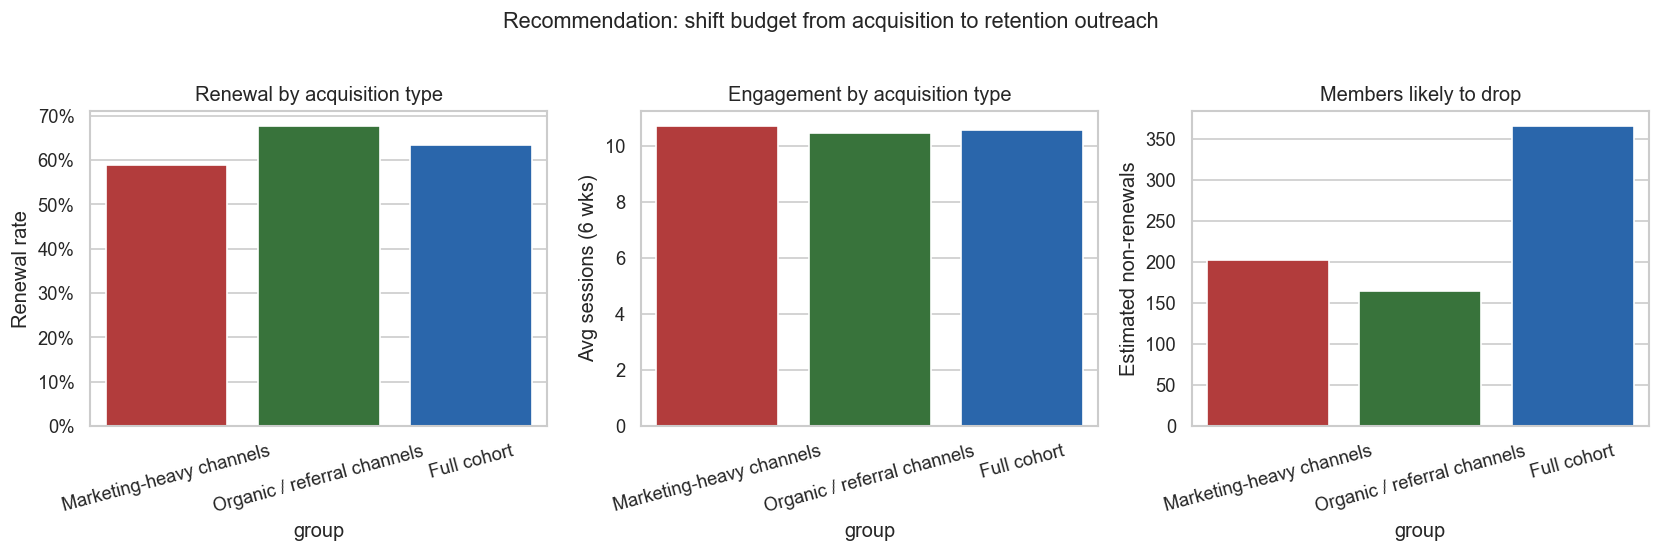

,group,members,renewal_rate,avg_sessions,at_risk_count
0,Marketing-heavy channels,492,0.59,10.71,202.0
1,Organic / referral channels,508,0.68,10.45,164.0
2,Full cohort,1000,0.63,10.58,366.0


In [10]:
#retention vs marketing spend argument
marketing_channels = ["fan_fest_pne", "fan_fest_surrey", "online_ad"]
retention_channels = ["referral", "walk_in", "open_house"]

mkt = df[df["signup_channel"].isin(marketing_channels)]
ret = df[df["signup_channel"].isin(retention_channels)]

summary = pd.DataFrame({
    "group": ["Marketing-heavy channels", "Organic / referral channels", "Full cohort"],
    "members": [len(mkt), len(ret), len(df)],
    "renewal_rate": [mkt["renewed_fall_season"].mean(), ret["renewed_fall_season"].mean(), df["renewed_fall_season"].mean()],
    "avg_sessions": [mkt["total_sessions"].mean(), ret["total_sessions"].mean(), df["total_sessions"].mean()],
})
summary["at_risk_count"] = (1 - summary["renewal_rate"]) * summary["members"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

sns.barplot(data=summary, x="group", y="renewal_rate", ax=axes[0], palette=[RED, GREEN, BLUE])
axes[0].set_ylabel("Renewal rate")
axes[0].yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
axes[0].set_title("Renewal by acquisition type")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=summary, x="group", y="avg_sessions", ax=axes[1], palette=[RED, GREEN, BLUE])
axes[1].set_ylabel("Avg sessions (6 wks)")
axes[1].set_title("Engagement by acquisition type")
axes[1].tick_params(axis="x", rotation=15)

sns.barplot(data=summary, x="group", y="at_risk_count", ax=axes[2], palette=[RED, GREEN, BLUE])
axes[2].set_ylabel("Estimated non-renewals")
axes[2].set_title("Members likely to drop")
axes[2].tick_params(axis="x", rotation=15)

plt.suptitle("Recommendation: shift budget from acquisition to retention outreach", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

summary.round(2)


Compares marketing-heavy channels, organic channels, and the full cohort. Supports marketing as first priority while showing retention gaps.


Technique selection

Problem 1 (renewal prediction) is supervised classification because renewed_fall_season is a known binary outcome. Logistic regression and random forest were compared with ROC-AUC against the client success criterion of a ranked at-risk list worth acting on.

Problem 2 (survey themes) is unsupervised pattern discovery because there is no predefined theme label. TF-IDF plus KMeans was chosen for short informal text; silhouette score guides cluster count but themes are interpreted against stakeholder success criteria.


Strategic option ranking


Survey silhouette score: 0.157


,rank,option,growth_and_momentum,capacity_and_access,retention_utility,total_score
0,1,Paid marketing campaign,0.516942,0.073800,0.041057,0.289
1,2,Expand pitch space,0.200000,0.570999,0.073200,0.286
2,3,Retention outreach system,0.046200,0.062700,0.518599,0.146


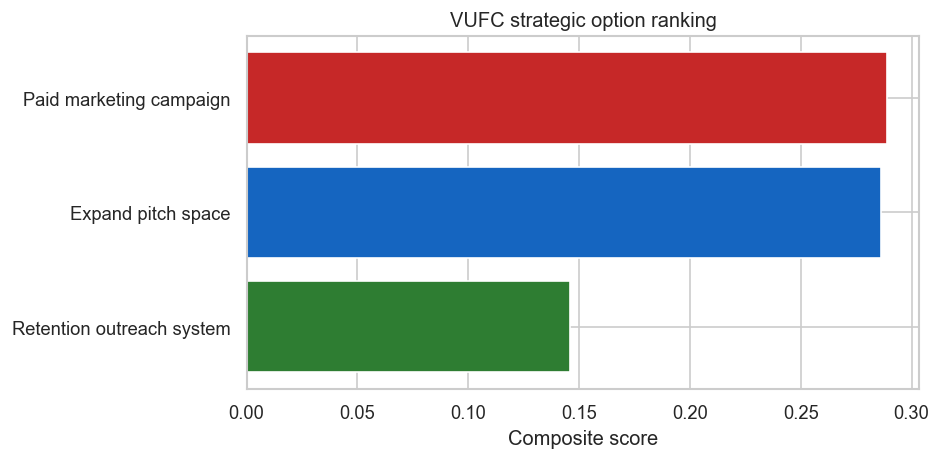

In [11]:
from src.modeling import train_renewal_model, build_survey_themes, compute_option_scores

model_result, df_scored = train_renewal_model(df)
survey_themes, silhouette, cluster_map = build_survey_themes(survey)
option_scores = compute_option_scores(df_scored, model_result, survey_themes)

print(f"Survey silhouette score: {silhouette:.3f}")
display(option_scores[["rank", "option", "growth_and_momentum", "capacity_and_access", "retention_utility", "total_score"]])

fig, ax = plt.subplots(figsize=(8, 4))
opts = option_scores.sort_values("total_score")
ax.barh(opts["option"], opts["total_score"], color=[GREEN, BLUE, RED])
ax.set_xlabel("Composite score")
ax.set_title("VUFC strategic option ranking")
plt.tight_layout()
plt.show()


Ranks the three client options using signup momentum, survey demand, pitch access pressure, and retention model utility. Marketing ranks first, expand pitch second, retention system third.


Assumptions log

renewed_fall_season is treated as accurate ground truth.
Six weeks of attendance is sufficient to predict fall renewal.
Missing distance is imputed with the median inside the model pipeline.
Missing prior experience is coded as unknown.
Survey themes describe respondents only; about 34% response rate.
Six clusters chosen to match client request for four to six themes.
Option ranking weights growth and momentum highest per VP decision framing.


Limitations

Single World Cup cohort with no prior season comparison.
Synthetic data may not match real VUFC patterns.
Survey selection bias across channels.
No causal proof that outreach changes renewal outcomes.
Pitch GeoJSON not used for travel-time modeling.
Option scores are a structured decision aid, not a full cost-benefit analysis.


Conclusion

VUFC should prioritize a paid marketing campaign while World Cup interest is still active. Fan fest and online ad channels delivered the largest signup volume and survey themes show continued demand for youth programs and casual play. Expand pitch space is the second priority because a meaningful share of members live far from existing pitches and the cohort exceeds comfortable capacity. The retention outreach system ranks third, the renewal model, test AUC about 0.71 produces a ranked at risk list worth using, but it supports the growth strategy rather than replacing it. Recommended sequence: market to fill programs, expand access, then use model scores to retain new signups.
